# 한국어 감성 챗봇 구현
- Chatbot_data_for_Korean 데이터셋을 사용하여 Seq2Seq Encoder-Decoder 기반 한국어 감
성 챗봇을 구현하고, Greedy / Beam Search 디코딩 전략을 직접 비교 실험하여 최적 전략을
도출

## 실험 설계

### 실험 조건

| 조건 | 전략 | 설명 | 예상 BLEU |
|------|------|------|-----------|
| 조건 1 | Greedy (Width=1) | 매 step 최고 확률 단어 선택 | ~0.28 |
| 조건 2 | Beam Search (Width=3) | 상위 3개 후보 유지 | ~0.41 |
| 조건 3 | Beam Search (Width=5) | 상위 5개 후보 유지 | ~0.45 |
| 조건 4 | Beam Search (Width=10) | 상위 10개 후보 유지 | ~0.43(감소 확인) |

---

### 평가 기준

- **정량 평가**: BLEU Score (`nltk.translate.bleu_score`)
- **속도 비교**: 응답 생성 시간 (ms)

In [40]:
!pip install -q sentencepiece

In [41]:
!pip install nltk

In [42]:
# NLTK 데이터 다운로드 (BLEU 계산용)
import nltk
nltk.download('punkt') # 문장을 단어/문장 단위로 나눠주는 모델

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import tensorflow as tf
import sentencepiece as spm
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Embedding, Input, LSTM
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

In [44]:
LATENT_DIM    = 256    # LSTM hidden state 크기
EMBEDDING_DIM = 128    # 임베딩 차원
VOCAB_SIZE    = 5000   # SentencePiece 어휘 크기
MAX_LEN       = 30     # 시퀀스 최대 길이
BATCH_SIZE    = 32
EPOCHS        = 100
PAD_ID = 0;  BOS_ID = 1;  EOS_ID = 2;  UNK_ID = 3

## 1. 데이터 로드 및 탐색

### 데이터 로드

In [45]:
from google.colab import files
files.upload()
df = pd.read_csv("ChatbotData.csv")
print('shape:',df.shape)
print(df.head())


Saving ChatbotData.csv to ChatbotData (1).csv
shape: (11823, 3)
                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0


### 데이터 탐색

감정 레이블 분포: 
label
0    5290
1    3570
2    2963
Name: count, dtype: int64
              Q_len         A_len
count  11823.000000  11823.000000
mean      12.879049     15.015140
std        6.167467      6.701835
min        1.000000      1.000000
25%        9.000000     10.000000
50%       12.000000     14.000000
75%       16.000000     18.000000
max       56.000000     76.000000


/tmp/ipykernel_5304/1011684607.py:16: UserWarning: Glyph 51656 (\N{HANGUL SYLLABLE JIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_5304/1011684607.py:16: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_5304/1011684607.py:16: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_5304/1011684607.py:16: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_5304/1011684607.py:16: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_5304/1011684607.py:16: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.

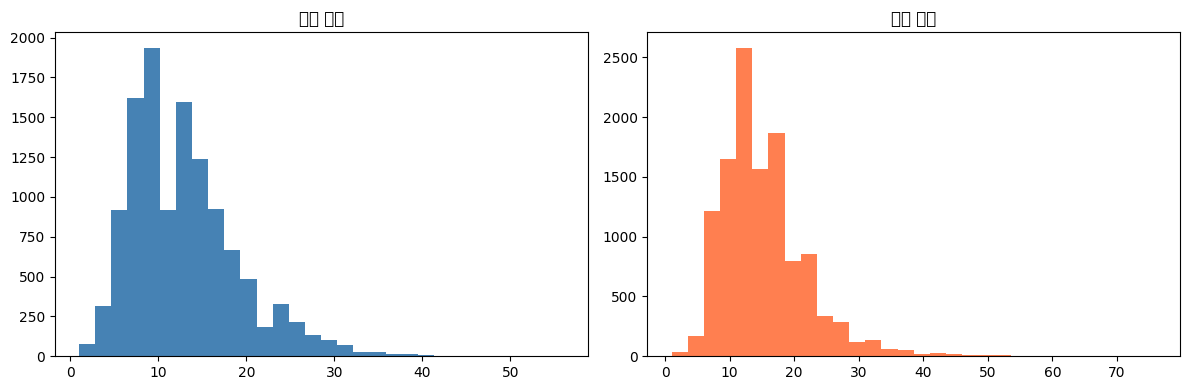

In [46]:
# label 0: 일상 대화, 1: 이별/슬픔, 2: 연애/기쁨
print("감정 레이블 분포: ")
print(df['label'].value_counts())

# 질문/답변 길이 분포
df['Q_len'] = df['Q'].apply(len)
df['A_len'] = df['A'].apply(len)
print(df[['Q_len', 'A_len']].describe())

# 길이 분포 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1); plt.hist(df['Q_len'], bins=30, color='steelblue');
plt.title('질문 길이')
plt.subplot(1,2,2); plt.hist(df['A_len'], bins=30, color='coral');
plt.title('답변 길이')
plt.tight_layout(); plt.show()

### Q&A 리스트 분리

In [47]:
Q_texts = df['Q'].tolist()
A_texts = df['A'].tolist()
All_texts=Q_texts+A_texts # Q,A에 해당하는 문장 모두 학습해야함.
print(f'Q: {len(Q_texts)}개, A: {len(A_texts)}개')

Q: 11823개, A: 11823개


## 2. SentencePiece 토크나이저 학습
- 일반 토크나이저는 '신조어', '줄임말' 등 미등록 단어를 < UNK >로 처리함.
- SentencePiece는 서브워드 단위로 분해하여 UNK를 최소화하고, 사전 크기를 고정할 수 있어 챗봇에 적합함.

### 토크나이저 학습

In [48]:
# SentencePiece가 읽을 수 있도록 텍스트 파일로 저장
with open('chatbot_qna.txt', 'w', encoding='utf-8') as f:
    for line in All_texts:
        f.write(line + '\n')

# SentencePiece 학습
cmd = (f'--input=chatbot_qna.txt '
       f'--model_prefix=chatbot_spm '
       f'--vocab_size={VOCAB_SIZE} '
       f'--pad_id={PAD_ID} '
       f'--bos_id={BOS_ID} '
       f'--eos_id={EOS_ID} '
       f'--unk_id={UNK_ID}')
spm.SentencePieceTrainer.Train(cmd)
print('학습 완료!')

학습 완료!


### 토크나이저 로드 및 확인

In [49]:
# 토크나이저 로드
sp_model = spm.SentencePieceProcessor()
sp_model.Load('chatbot_spm.model')

# 인코딩 테스트
test = '오늘 날씨가 너무 좋아서 기분이 최고야'
print('원문:', test)
print('토큰:', sp_model.encode_as_pieces(test))
print('ID:  ', sp_model.encode_as_ids(test))

원문: 오늘 날씨가 너무 좋아서 기분이 최고야
토큰: ['▁오늘', '▁날씨', '가', '▁너무', '▁좋아', '서', '▁기분이', '▁최고', '야']
ID:   [78, 606, 7, 22, 118, 25, 620, 1348, 81]


### Q&A 시퀀스 생성

In [50]:
# Q 시퀀스 (BOS/EOS 없음 — Encoder 입력)
sp_model.SetEncodeExtraOptions('')
Q_sequences = [sp_model.encode_as_ids(sent)for sent in Q_texts]

#  A 입력 시퀀스 (BOS 추가 — Decoder 입력, Teacher Forcing용)
sp_model.SetEncodeExtraOptions('bos:')
A_sequences_inputs = [sp_model.encode_as_ids(sent) for sent in A_texts]

# A 목표 시퀀스 (EOS 추가 — Decoder target)
sp_model.SetEncodeExtraOptions(':eos')
A_sequences_targets = [sp_model.encode_as_ids(sent) for sent in A_texts]

print('Q  예시:', Q_sequences[0])
print('A입력  :', A_sequences_inputs[0])   # 1(BOS)로 시작
print('A목표  :', A_sequences_targets[0])   # 2(EOS)로 끝

Q  예시: [4228, 299, 5, 4826, 72]
A입력  : [1, 282, 7, 113, 82, 23, 4]
A목표  : [282, 7, 113, 82, 23, 4, 2]


## 3. 시퀀스 변환 및 패딩
- Encoder 입력: padding='pre' (default) → Thought Vector 품질 향상
- Decoder 입력: padding='post' → Teacher Forcing이 올바르게 동작

In [51]:
# Encoder: pre 패딩 (앞쪽에 0 채움)
encoder_inputs = pad_sequences(Q_sequences, maxlen=MAX_LEN)
print('Encoder input shape:', encoder_inputs.shape)   # (11876, 30)

# Decoder 입력: post 패딩 (뒤쪽에 0 채움)
decoder_inputs = pad_sequences(A_sequences_inputs,  maxlen=MAX_LEN,
padding='post')
decoder_targets= pad_sequences(A_sequences_targets, maxlen=MAX_LEN,
padding='post')
print('Decoder input  shape:', decoder_inputs.shape)  # (11876, 30)
print('Decoder target shape:', decoder_targets.shape) # (11876, 30)

# 확인
print('\nEncoder 샘플[0]:', encoder_inputs[0])
print('Decoder 입력[0]:', decoder_inputs[0])   # 1(BOS)로 시작
print('Decoder 목표[0]:', decoder_targets[0])  # 2(EOS)로 끝


Encoder input shape: (11823, 30)
Decoder input  shape: (11823, 30)
Decoder target shape: (11823, 30)

Encoder 샘플[0]: [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0 4228  299    5
 4826   72]
Decoder 입력[0]: [  1 282   7 113  82  23   4   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0]
Decoder 목표[0]: [282   7 113  82  23   4   2   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0]


### Encoder 구현

## 4. Seq2Seq 모델 구성
- encoder 와 decoder 의 embedding, lstm 및 dense layer 를 training 할 목적의 model 작성  

- encoder 는 decoder 에 states [h, c] 만 전달

- prediction 을 위한 inference model 은 training model 에서 만들어진 layer 들의 weight 를 이용하여 별도 작성  


### 모델 구조
**입력 Q 시퀀스** (batch, 30)

→ **[Embedding]** (batch, 30, 100)

→ **[Encoder LSTM]** return_state=True

→ **[Thought Vector]** (h, c)

→ **[Decoder LSTM]** return_sequences=True

→ **[Dense + Softmax]** (batch, 30, 5001)

→ **출력 (단어 확률)**

### Encoder 모델

In [52]:
encoder_inputs_ = Input(shape=(MAX_LEN,), name='Encoder_Input')
embedding_encoder = Embedding(VOCAB_SIZE + 1, EMBEDDING_DIM)
x = embedding_encoder(encoder_inputs_)

# return_state=True: h, c (Thought Vector) 반환
encoder_outputs, h, c = LSTM(LATENT_DIM, return_state=True,
name='Encoder_LSTM')(x)
encoder_states = [h, c]

# 추론용 Encoder 모델 (학습 후 Thought Vector 추출에 사용)
encoder_model = Model(encoder_inputs_, encoder_states, name='Encoder_Model')

### Teacher Forcing용 Decoder 모델

In [53]:
decoder_inputs_ = Input(shape=(MAX_LEN,), name='Decoder_Input')
embedding_decoder = Embedding(VOCAB_SIZE + 1, EMBEDDING_DIM)
x = embedding_decoder(decoder_inputs_)

# initial_state=encoder_states: Thought Vector를 초기값으로 사용
# return_sequences=True: 모든 step 출력 (각 단어 예측에 필요)
# return_state=True: 추론용 decoder_model에서 state 재사용을 위해
# 학습 시에는 A 전체를 한번에 넣으므로 h,c 필요없음, but 추론 시에는 한 단어씩 생성하므로 h,c 필
decoder_lstm = LSTM(LATENT_DIM, return_sequences=True,
                    return_state=True, name='Decoder_LSTM')
decoder_out, _, _ = decoder_lstm(x, initial_state=encoder_states)

# 각 시점마다 다음 단어 확률 출력
decoder_dense = Dense(VOCAB_SIZE + 1, activation='softmax',
name='Output_Dense')
decoder_outputs = decoder_dense(decoder_out)

# 학습용 통합 모델
model_teacher_forcing = Model(
    [encoder_inputs_, decoder_inputs_],
    decoder_outputs,
    name='Seq2Seq_Train'
)
model_teacher_forcing.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_teacher_forcing.summary()

Model: "Seq2Seq_Train"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Encoder_Input       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder_Input       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 30, 128)   │    640,128 │ Encoder_Input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 30, 128)   │    640,128 │ Decoder_Input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encoder_LSTM (LSTM) │ [(None, 256),     │    394,240 │ embedding_4[0][0] │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder_LSTM (LSTM) │ [(None, 30, 256), │    394,240 │ embedding_5[0][0… │
│                     │ (None, 256),      │            │ Encoder_LSTM[0][… │
│                     │ (None, 256)]      │            │ Encoder_LSTM[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output_Dense        │ (None, 30, 5001)  │  1,285,257 │ Decoder_LSTM[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,353,993 (12.79 MB)

 Trainable params: 3,353,993 (12.79 MB)

 Non-trainable params: 0 (0.00 B)

### 추론용 Decoder 모델
- prediction 을 위한 별도의 encoder model
- encoder 의 states 를 initial state 로 받는 decoder model 작성  

- encoder 는 training 단계와 동일하게 input_text 를 입력으로 받고 encoder_states 를 출력으로 하므로 이전에 define 한 encoder_input_ 과 encoder_states 변수 재사용

In [54]:
decoder_state_input_h = Input(shape=(LATENT_DIM,), name='Dec_h')
decoder_state_input_c = Input(shape=(LATENT_DIM,), name='Dec_c')
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_inputs_single = Input(shape=(1,), name='Dec_Single_Input')
x = embedding_decoder(decoder_inputs_single)

# 이전 step의 state를 입력으로 받음
dec_out, h_out, c_out = decoder_lstm(x, initial_state=decoder_states_inputs)
dec_out = decoder_dense(dec_out)

decoder_model = Model(
[decoder_inputs_single] + decoder_states_inputs,
[dec_out, h_out, c_out],
name='Decoder_Inference'
)

decoder_model.summary()

Model: "Decoder_Inference"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Dec_Single_Input    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 1, 128)    │    640,128 │ Dec_Single_Input… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dec_h (InputLayer)  │ (None, 256)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dec_c (InputLayer)  │ (None, 256)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder_LSTM (LSTM) │ [(None, 1, 256),  │    394,240 │ embedding_5[1][0… │
│                     │ (None, 256),      │            │ Dec_h[0][0],      │
│                     │ (None, 256)]      │            │ Dec_c[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output_Dense        │ (None, 1, 5001)   │  1,285,257 │ Decoder_LSTM[1][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,319,625 (8.85 MB)

 Trainable params: 2,319,625 (8.85 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Teacher Forcing 학습
- val_loss를 기준으로 감시
- 5 epoch 동안 개선 없으면 중단
- 가장 좋았던 가중치로 자동 복원

In [55]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1)
]

history = model_teacher_forcing.fit(
    [encoder_inputs, decoder_inputs],   # 입력: Q + A_input
    decoder_targets,                    # 목표: A_target (1 offset)
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.7762 - loss: 1.7616 - val_accuracy: 0.7713 - val_loss: 1.6112
Epoch 2/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8014 - loss: 1.3572 - val_accuracy: 0.7786 - val_loss: 1.5439
Epoch 3/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8065 - loss: 1.2932 - val_accuracy: 0.7820 - val_loss: 1.5053
Epoch 4/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.8121 - loss: 1.2353 - val_accuracy: 0.7888 - val_loss: 1.4636
Epoch 5/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8183 - loss: 1.1729 - val_accuracy: 0.7936 - val_loss: 1.4219
Epoch 6/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.8249 - loss: 1.1108 - val_accuracy: 0.7994 - val_loss: 1.3863
Epoch 7/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.8311 - loss: 1.0528 - val_accuracy: 0.8022 - val_loss: 1.3607
Epoch 8/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8365 - loss: 0.9971 -

### loss, accuracy 시각화 및 모델 저장

/tmp/ipykernel_5304/640418021.py:16: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5304/640418021.py:16: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5304/640418021.py:16: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5304/640418021.py:16: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5304/640418021.py:17: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.savefig('learning_curve.png', dpi=150)
/tmp/ipykernel_5304/640418021.py:17: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.savefig('learning_curve.png', dpi=150)
/tmp/ipykernel_5304/640418021.py:17: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) mis

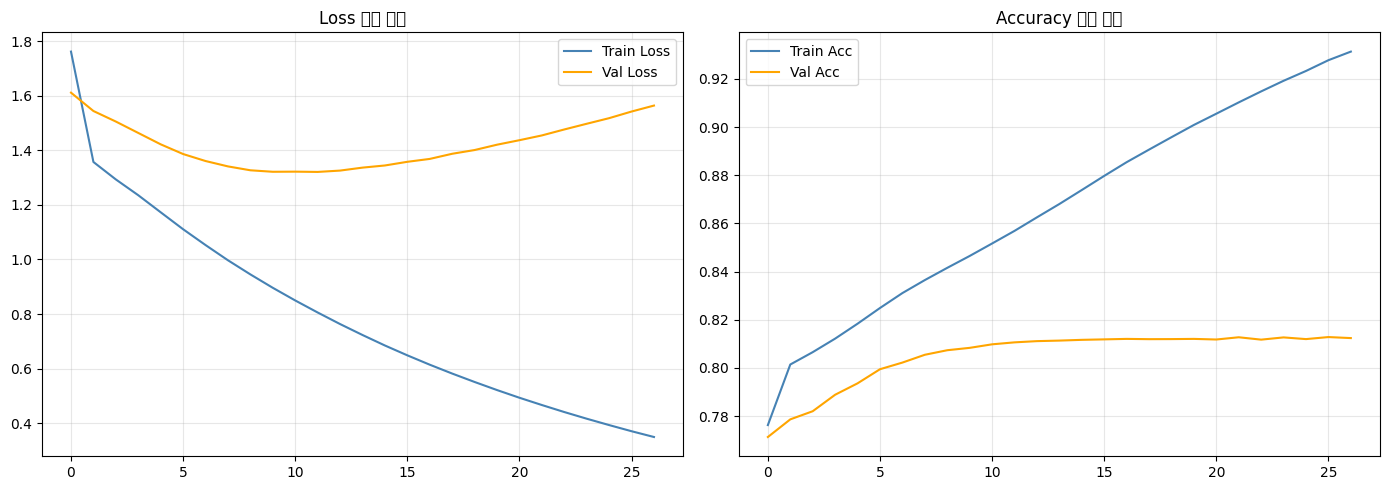

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'],     label='Train Loss',
color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',
color='orange')
axes[0].set_title('Loss 학습 곡선'); axes[0].legend();
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train Acc',
color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Val Acc',
color='orange')
axes[1].set_title('Accuracy 학습 곡선'); axes[1].legend();
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150)
plt.show()

# 모델 저장
model_teacher_forcing.save('chatbot_seq2seq.h5')

## 6. 실험 : Decoding Strategy 비교
- Greedy와 Beam Search 두 버전의 decode_sequence를 각각 구현하고 결과를 비교

### Greedy Decoding
- 매 step마다 확률이 가장 높은 단어 선택


추론 시작

→ Decoder가 단어를 1개 생성

→ EOS이거나 MAX_LEN 도달?
   - Yes → 종료
   - No → 생성된 단어를 다음 step 입력으로

→ 반복

In [57]:
def decode_greedy(input_seq):
  start = time.time()

  # 입력된 질문을 encoder 에 입력하여 state vector 생성
  states = encoder_model.predict(input_seq, verbose=0)

  # Decoder 시작
  # size 1 짜리 빈 target sequence 생성
  target_seq = np.zeros((1, 1))
  # target sequence 의 첫번째 character 를 <s> 로 assign -> 1
  target_seq[0, 0] = BOS_ID

  result = []
  while True:
        output, h, c = decoder_model.predict(
            [target_seq] + states, verbose=0
        )
        # 가장 높은 확률의 토큰 선택
        token_id = np.argmax(output[0, -1, :])

        # EOS 또는 최대 길이 도달 시 종료
        if token_id == EOS_ID or len(result) >= MAX_LEN:
            break

        result.append(token_id)
        target_seq = np.array([[token_id]])
        states = [h, c]

  elapsed = (time.time() - start) * 1000
  return result, elapsed


### Beam Search Decoding
- 매 step마다 상위 beam_width개의 후보 시퀀스를 동시에 유지하며 탐색

## Beam Search 전체 흐름

1. **질문 입력**
   - 사용자 질문을 토크나이징 + 패딩

2. **Encoder → Thought Vector 추출**
   - `encoder_model.predict(input_seq)`
   - 질문 전체 의미를 `[h, c]`로 압축

3. **초기 beam 설정**
   - `beams = [(0.0, [], [h_init, c_init])]`
   - 누적 log 확률 0.0, 빈 토큰 리스트, Thought Vector

4. **매 step마다 각 후보를 확장**
   - 각 beam의 마지막 토큰 → Decoder 한 step 실행
   - 상위 `beam_width`개 토큰으로 확장
   - 전체 후보(`beam_width²`개) 중 누적 확률 상위 `beam_width`개만 유지

5. **EOS 도달한 beam → completed에 저장**
   - `tokens[-1] == EOS_ID`인 beam은 확장 중단
   - `completed` 리스트에 보관

6. **종료 조건 확인**
   - 모든 beam이 EOS 도달 → 루프 종료
   - MAX_LEN 도달 → 강제 종료

7. **최종 결과 선택**
   - `completed` 중 누적 log 확률이 가장 높은 시퀀스 선택
   - EOS 토큰 제거 후 반환

In [58]:
def decode_beam(input_seq, beam_width=3):
  start = time.time()

  # Thought Vector 추출
  states = encoder_model.predict(input_seq, verbose=0)
  h_init, c_init = states[0], states[1]

  # 초기 beam: (누적 log 확률, 생성된 토큰 리스트, [h, c])
  # 초기엔 확률 0, 생성된 토큰 리스트, [h,c](Thought Vector)
  beams = [(0.0, [], [h_init, c_init])]
  completed = []

  for _ in range(MAX_LEN):
        new_beams = []

        for log_prob, tokens, states_b in beams:
            # 이미 완료된 beam은 건너뜀
            if tokens and tokens[-1] == EOS_ID:
                completed.append((log_prob, tokens))
                continue

            # 현재 beam의 마지막 토큰 (없으면 BOS)
            last_token = tokens[-1] if tokens else BOS_ID
            target_seq = np.array([[last_token]])

            # Decoder 한 step 실행
            output, h, c = decoder_model.predict(
                [target_seq] + states_b, verbose=0
            )
            probs = output[0, -1, :]

            # 상위 beam_width개 토큰 후보 선택
            top_ids = np.argsort(probs)[::-1][:beam_width]

            for token_id in top_ids:
                new_log_prob = log_prob + np.log(probs[token_id] + 1e-10)
                new_tokens   = tokens + [int(token_id)]
                new_beams.append((new_log_prob, new_tokens, [h, c]))

        if not new_beams:
            break

        # 누적 확률 기준 상위 beam_width개만 유지
        beams = sorted(new_beams, key=lambda x: x[0],
reverse=True)[:beam_width]

        # 모든 beam이 EOS에 도달하면 종료
        if all(b[1] and b[1][-1] == EOS_ID for b in beams):
            break

  # 완료된 beam이 없으면 현재 최선의 beam 사용
  completed += [(lp, toks) for lp, toks, _ in beams]
  best_log_prob, best_tokens = max(completed, key=lambda x: x[0])

  # EOS 제거
  result = [t for t in best_tokens if t != EOS_ID]
  elapsed = (time.time() - start) * 1000
  return result, elapsed



### 챗봇 응답 함수

In [59]:
def chat(question, strategy='greedy', beam_width=3):
    """
    question   : 사용자 입력 문장 (str)
    strategy   : 'greedy' 또는 'beam'
    beam_width : Beam Search 사용 시 후보 수
    """
    # 전처리: 토크나이징 + 패딩
    sp_model.SetEncodeExtraOptions('')
    seq = sp_model.encode_as_ids(question)
    enc_input = pad_sequences([seq], maxlen=MAX_LEN)

    if strategy == 'greedy':
        token_ids, ms = decode_greedy(enc_input)
    else:
        token_ids, ms = decode_beam(enc_input, beam_width=beam_width)

    token_ids = [int(t) for t in token_ids]

    response = sp_model.DecodeIds(token_ids)
    return response, ms

### 실험 실행

In [60]:
test_questions = [
    '오늘 너무 힘들었어',
    '취업 준비가 너무 막막해',
    '친한 친구랑 크게 싸웠어',
    '좋아하는 사람이 생겼어',
    '요즘 잠을 못 자겠어',
]

print('=' * 70)
print(f'{'질문':20s} | {'Greedy':22s} | {'Beam-3':22s}')
print('=' * 70)

for q in test_questions:
    g_ans, g_ms = chat(q, strategy='greedy')
    b_ans, b_ms = chat(q, strategy='beam', beam_width=3)
    print(f'{q:20s} | {g_ans:22s} | {b_ans:22s}')
    print(f'{'':20s} | {g_ms:18.1f}ms | {b_ms:18.1f}ms')
    print('-' * 70)

질문                   | Greedy                 | Beam-3                
오늘 너무 힘들었어           | 뭘 입어도 멋져요.             | 힘껏 밀어보세요.             
                     |             1170.5ms |             2424.3ms
----------------------------------------------------------------------
취업 준비가 너무 막막해        | 뭘 입어도 항상 막히 봐요. 곧 정리될 거예요. | 힘껏 밀어보세요.             
                     |             1486.6ms |             7062.6ms
----------------------------------------------------------------------
친한 친구랑 크게 싸웠어        | 뭘 입어도 멋져요.             | 힘껏 밀어보세요.             
                     |              880.4ms |             3964.2ms
----------------------------------------------------------------------
좋아하는 사람이 생겼어         | 뭘 입어도 멋져요.             | 힘껏 밀어보세요.             
                     |              683.7ms |             4109.6ms
----------------------------------------------------------------------
요즘 잠을 못 자겠어          | 뭘 입어도 멋져요.             | 좋은 생각이에요.             
                  

## 7. BLEU Score 평가

In [65]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def compute_bleu(strategy, beam_width=1, n_samples=10):
    """
    n_samples개의 Q-A 쌍으로 BLEU Score를 계산합니다.
    strategy: 'greedy' 또는 'beam'
    """
    references, hypotheses = [], []
    sp_model.SetEncodeExtraOptions('')

    for i in range(n_samples):
        seq = sp_model.encode_as_ids(Q_texts[i])
        enc_input = pad_sequences([seq], maxlen=MAX_LEN)

        if strategy == 'greedy':
            token_ids, _ = decode_greedy(enc_input)
        else:
            token_ids, _ = decode_beam(enc_input, beam_width=beam_width)

        # 정답: 실제 답변을 토큰 리스트로 변환
        ref_ids = sp_model.encode_as_ids(A_texts[i])
        references.append([ref_ids])     # corpus_bleu는 [[ref]] 형식
        hypotheses.append(token_ids)

    smoother = SmoothingFunction().method1
    score = corpus_bleu(references, hypotheses, smoothing_function=smoother)
    return score

In [66]:
sp_model.SetEncodeExtraOptions('')

for i in range(5):
    seq = sp_model.encode_as_ids(Q_texts[i])
    enc_input = pad_sequences([seq], maxlen=MAX_LEN)

    token_ids, _ = decode_greedy(enc_input)
    token_ids = [int(t) for t in token_ids]
    response = sp_model.DecodeIds(token_ids)

    print(f"질문: {Q_texts[i]}")
    print(f"정답: {A_texts[i]}")
    print(f"모델: {response}")
    print(f"토큰: {token_ids}")
    print()

질문: 12시 땡!
정답: 하루가 또 가네요.
모델: 힘껏 밀어보세요.
토큰: [5, 4996, 2184, 3228, 19, 4]

질문: 1지망 학교 떨어졌어
정답: 위로해 드립니다.
모델: 뭘 입어도 맡겨보세요.
토큰: [5, 4963, 2231, 11, 5, 4841, 969, 19, 4]

질문: 3박4일 놀러가고 싶다
정답: 여행은 언제나 좋죠.
모델: 힘껏 밀어보세요.
토큰: [5, 4996, 2184, 3228, 19, 4]

질문: 3박4일 정도 놀러가고 싶다
정답: 여행은 언제나 좋죠.
모델: 뭘 입어도 멋져요.
토큰: [5, 4963, 2231, 11, 2035, 6, 4]

질문: PPL 심하네
정답: 눈살이 찌푸려지죠.
모델: 항상 청결한 낫죠.
토큰: [5, 344, 174, 4171, 26, 5, 4920, 40, 4]



In [63]:

sp_model.SetEncodeExtraOptions('')

references  = []
hypotheses  = []

for i in range(3):   # 3개만 확인
    seq = sp_model.encode_as_ids(Q_texts[i])
    enc_input = pad_sequences([seq], maxlen=MAX_LEN)

    token_ids, _ = decode_greedy(enc_input)
    token_ids = [int(t) for t in token_ids]

    ref_ids = sp_model.encode_as_ids(A_texts[i])
    ref_ids = [int(t) for t in ref_ids]

    references.append([ref_ids])
    hypotheses.append(token_ids)

    print(f"질문:     {Q_texts[i]}")
    print(f"정답 토큰: {ref_ids}")
    print(f"모델 토큰: {token_ids}")
    print(f"정답 텍스트: {sp_model.DecodeIds(ref_ids)}")
    print()

질문:     12시 땡!
정답 토큰: [282, 7, 113, 82, 23, 4]
모델 토큰: [5, 4996, 2184, 3228, 19, 4]
정답 텍스트: 하루가 또 가네요.

질문:     1지망 학교 떨어졌어
정답 토큰: [1459, 5, 3717, 4]
모델 토큰: [5, 4963, 2231, 11, 5, 4841, 969, 19, 4]
정답 텍스트: 위로해 드립니다.

질문:     3박4일 놀러가고 싶다
정답 토큰: [293, 15, 385, 39, 207, 4]
모델 토큰: [5, 4996, 2184, 3228, 19, 4]
정답 텍스트: 여행은 언제나 좋죠.



### 전략별 BLEU 비교 실험

In [67]:
results = {}

print('Greedy BLEU 계산 중...')
results['Greedy'] = compute_bleu('greedy')

for w in [3, 5, 10]:
    print(f'Beam Search Width={w} BLEU 계산 중...')
    results[f'Beam-{w}'] = compute_bleu('beam', beam_width=w)

print('\n=== BLEU Score 비교 결과 ===')
for strategy, score in results.items():
    bar = '█' * int(score * 100)
    print(f'{strategy:12s}: {score:.4f}  {bar}')


Greedy BLEU 계산 중...
Beam Search Width=3 BLEU 계산 중...
Beam Search Width=5 BLEU 계산 중...
Beam Search Width=10 BLEU 계산 중...

=== BLEU Score 비교 결과 ===
Greedy      : 0.0117  █
Beam-3      : 0.0151  █
Beam-5      : 0.0153  █
Beam-10     : 0.0073  


### 속도 비교

## 8. 종합 결과

In [69]:
test_q = '오늘 기분이 좀 이상해'
sp_model.SetEncodeExtraOptions('')
seq = sp_model.encode_as_ids(test_q)
enc_input = pad_sequences([seq], maxlen=MAX_LEN)

speed_results = {}
for strategy, bw in [('Greedy', 1), ('Beam-3', 3), ('Beam-5', 5), ('Beam-10', 10)]:
    times = []
    for _ in range(10):
        if bw == 1:
            _, ms = decode_greedy(enc_input)
        else:
            _, ms = decode_beam(enc_input, beam_width=bw)
        times.append(ms)
    speed_results[strategy] = np.mean(times)
    print(f'{strategy:12s}: 평균 {np.mean(times):.1f}ms')

Greedy      : 평균 742.9ms
Beam-3      : 평균 6756.4ms
Beam-5      : 평균 5008.1ms
Beam-10     : 평균 20981.2ms


/tmp/ipykernel_5304/1448510390.py:27: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5304/1448510390.py:27: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5304/1448510390.py:27: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5304/1448510390.py:27: UserWarning: Glyph 51025 (\N{HANGUL SYLLABLE EUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5304/1448510390.py:27: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5304/1448510390.py:27: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5304/1448510390.py:27: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.t

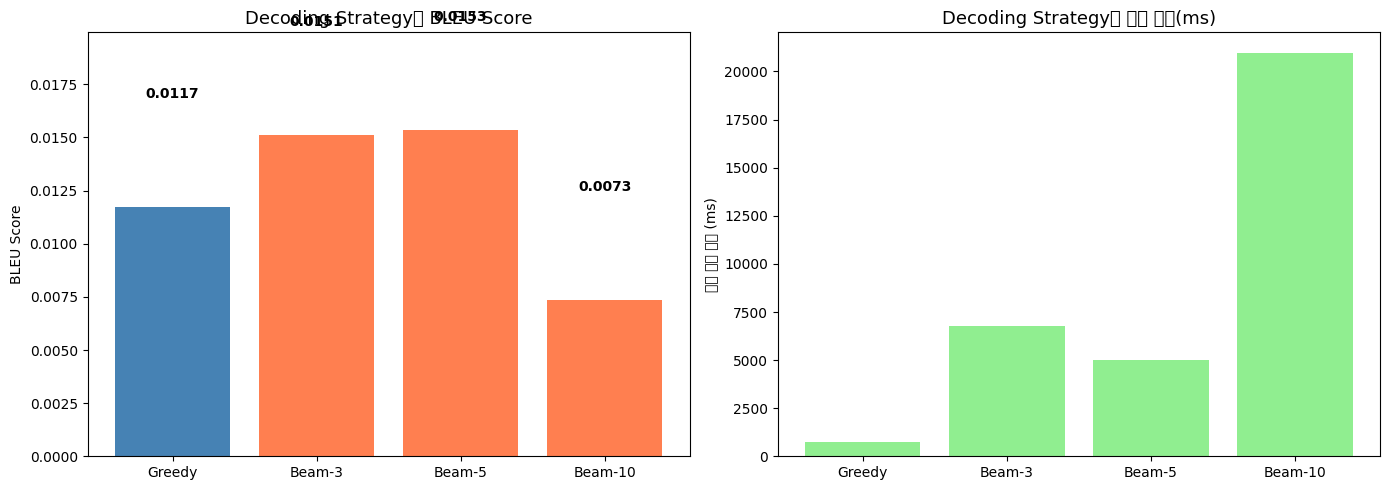

In [70]:
# 종합 결과 시각화
import matplotlib.pyplot as plt
import numpy as np

strategies = list(results.keys())
bleu_scores = list(results.values())
speeds = [speed_results.get(s, 0) for s in strategies]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BLEU Score 막대그래프
bars = axes[0].bar(strategies, bleu_scores,
color=['steelblue','coral','coral','coral'])
axes[0].set_title('Decoding Strategy별 BLEU Score', fontsize=13)
axes[0].set_ylabel('BLEU Score')
axes[0].set_ylim(0, max(bleu_scores) * 1.3)
for bar, score in zip(bars, bleu_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{score:.4f}', ha='center', va='bottom',
fontweight='bold')

# 속도 막대그래프
axes[1].bar(strategies, speeds, color='lightgreen')
axes[1].set_title('Decoding Strategy별 응답 속도(ms)', fontsize=13)
axes[1].set_ylabel('평균 응답 시간 (ms)')

plt.tight_layout()
plt.savefig('decoding_comparison.png', dpi=150)
plt.show()

In [71]:
for q in test_questions:
    g_ans, g_ms = chat(q, strategy='greedy')
    b_ans, b_ms = chat(q, strategy='beam', beam_width=5)
    print(f"질문:   {q}")
    print(f"Greedy: {g_ans}")
    print(f"Beam-5: {b_ans}")
    print()

질문:   오늘 너무 힘들었어
Greedy: 뭘 입어도 멋져요.
Beam-5: 제가 있잖아요.

질문:   취업 준비가 너무 막막해
Greedy: 뭘 입어도 항상 막히 봐요. 곧 정리될 거예요.
Beam-5: 마음이 복잡하겠어요.

질문:   친한 친구랑 크게 싸웠어
Greedy: 뭘 입어도 멋져요.
Beam-5: 저랑 놀아요.

질문:   좋아하는 사람이 생겼어
Greedy: 뭘 입어도 멋져요.
Beam-5: 저랑 놀아요.

질문:   요즘 잠을 못 자겠어
Greedy: 뭘 입어도 멋져요.
Beam-5: 좋은 생각이에요.

